# Punto 5 — V1.0 — Dashboard del partido (correcciones #4, leyenda shot maps, nombres bonitos)

**Proyecto Final V1.0** · Lucas Marinelli · @datafutbol_ar

> **Cambios respecto a V0:**
> - **#4 (Federico):** `wspace` reducido + paddings internos del Pitch → shot maps pegados, sin franja vacía en el medio.
> - **NUEVO V1.0:** agrego **leyenda explicativa de los shot maps** (faltaba en V0). Federico no la marcó pero al revisar la pieza me di cuenta de que el lector no sabe qué significa el celeste/dorado ni el tamaño.
> - **Bonus:** los nombres de los destacados ahora usan `nombres_bonitos.py` (ej. "Rodrigo De Paul" en lugar de "Rodrigo Paul").


## Setup

In [4]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

V0_PATH = Path('..').resolve() / 'Proyecto_Final_Lucas_Marinelli'
if str(V0_PATH) not in sys.path:
    sys.path.insert(0, str(V0_PATH))

from helpers import *

# === FIX V1.0: redefinir guardar_fig para que apunte a outputs_v1/ ===
OUTPUTS_V1_DIR = Path('outputs_v1').resolve()
OUTPUTS_V1_DIR.mkdir(exist_ok=True)
def guardar_fig(fig, nombre, dpi=200):
    ruta = OUTPUTS_V1_DIR / (nombre if nombre.endswith('.png') else f'{nombre}.png')
    fig.savefig(ruta, dpi=dpi, bbox_inches='tight', facecolor=fig.get_facecolor())
    print(f'[fig V1.0] guardada {ruta.name}')
    return ruta

from matplotlib.lines import Line2D
from matplotlib.patches import FancyBboxPatch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from mplsoccer import Pitch, VerticalPitch
from pases_progresivos import agregar_pases_progresivos
from nombres_bonitos import nombre_bonito

COLOR_OK     = "#07BD8C"
COLOR_NO_OK  = "#C52D12"

ev = cargar_eventos(MATCH_ARG_SAU, 'arg_sau')
ev = añadir_xy(ev)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
[cache] arg_sau: 3329 eventos leidos de eventos_arg_sau.parquet


## Stats agregadas

In [5]:
def stats_equipo(ev, equipo):
    ev_eq = ev[ev['team'] == equipo]
    tiros = ev_eq[ev_eq['type'] == 'Shot']
    pases = ev_eq[ev_eq['type'] == 'Pass']
    pases_ext = agregar_pases_progresivos(pases)
    return {
        'equipo': equipo,
        'goles': int((tiros['shot_outcome'] == 'Goal').sum()),
        'tiros': len(tiros),
        'tiros_al_arco': int(tiros['shot_outcome'].isin(['Goal','Saved','Saved To Post']).sum()),
        'xg': round(tiros['shot_statsbomb_xg'].sum(), 2),
        'pases_total': len(pases),
        'pases_ok': int(pases['pass_outcome'].isna().sum()),
        'acierto_pct': round(pases['pass_outcome'].isna().sum() / len(pases) * 100, 1),
        'pases_progresivos': int(pases_ext['es_progresivo'].sum()),
        'recuperaciones': int((ev_eq['type'] == 'Ball Recovery').sum()),
        'posesion': round(len(ev_eq) / len(ev) * 100, 1),
    }


def jugador_destacado(ev, equipo):
    pases = ev[(ev['type'] == 'Pass') & (ev['team'] == equipo)]
    pases_ext = agregar_pases_progresivos(pases)
    prog = pases_ext[pases_ext['es_progresivo']]
    if prog.empty: return None
    top = prog.groupby('player').size().sort_values(ascending=False)
    nombre = top.index[0]
    return {
        'nombre': nombre, 'equipo': equipo,
        'pases_progresivos': int(top.iloc[0]),
        'recuperaciones': int((ev[(ev['player'] == nombre) & (ev['type'] == 'Ball Recovery')]).shape[0]),
    }


stats_arg = stats_equipo(ev, 'Argentina')
stats_sau = stats_equipo(ev, 'Saudi Arabia')
dest_arg = jugador_destacado(ev, 'Argentina')
dest_sau = jugador_destacado(ev, 'Saudi Arabia')
print('Destacados (con nombres bonitos):')
print(f'  ARG: {nombre_bonito(dest_arg["nombre"], formato="completo")}')
print(f'  SAU: {nombre_bonito(dest_sau["nombre"], formato="completo")}')


Destacados (con nombres bonitos):
  ARG: Rodrigo De Paul
  SAU: Mohammed Kanoo


## Dashboard A V1.0 — shot maps pegados + leyenda explicativa + nombres bonitos

[fig V1.0] guardada punto5_dashboard_partido_v1.png


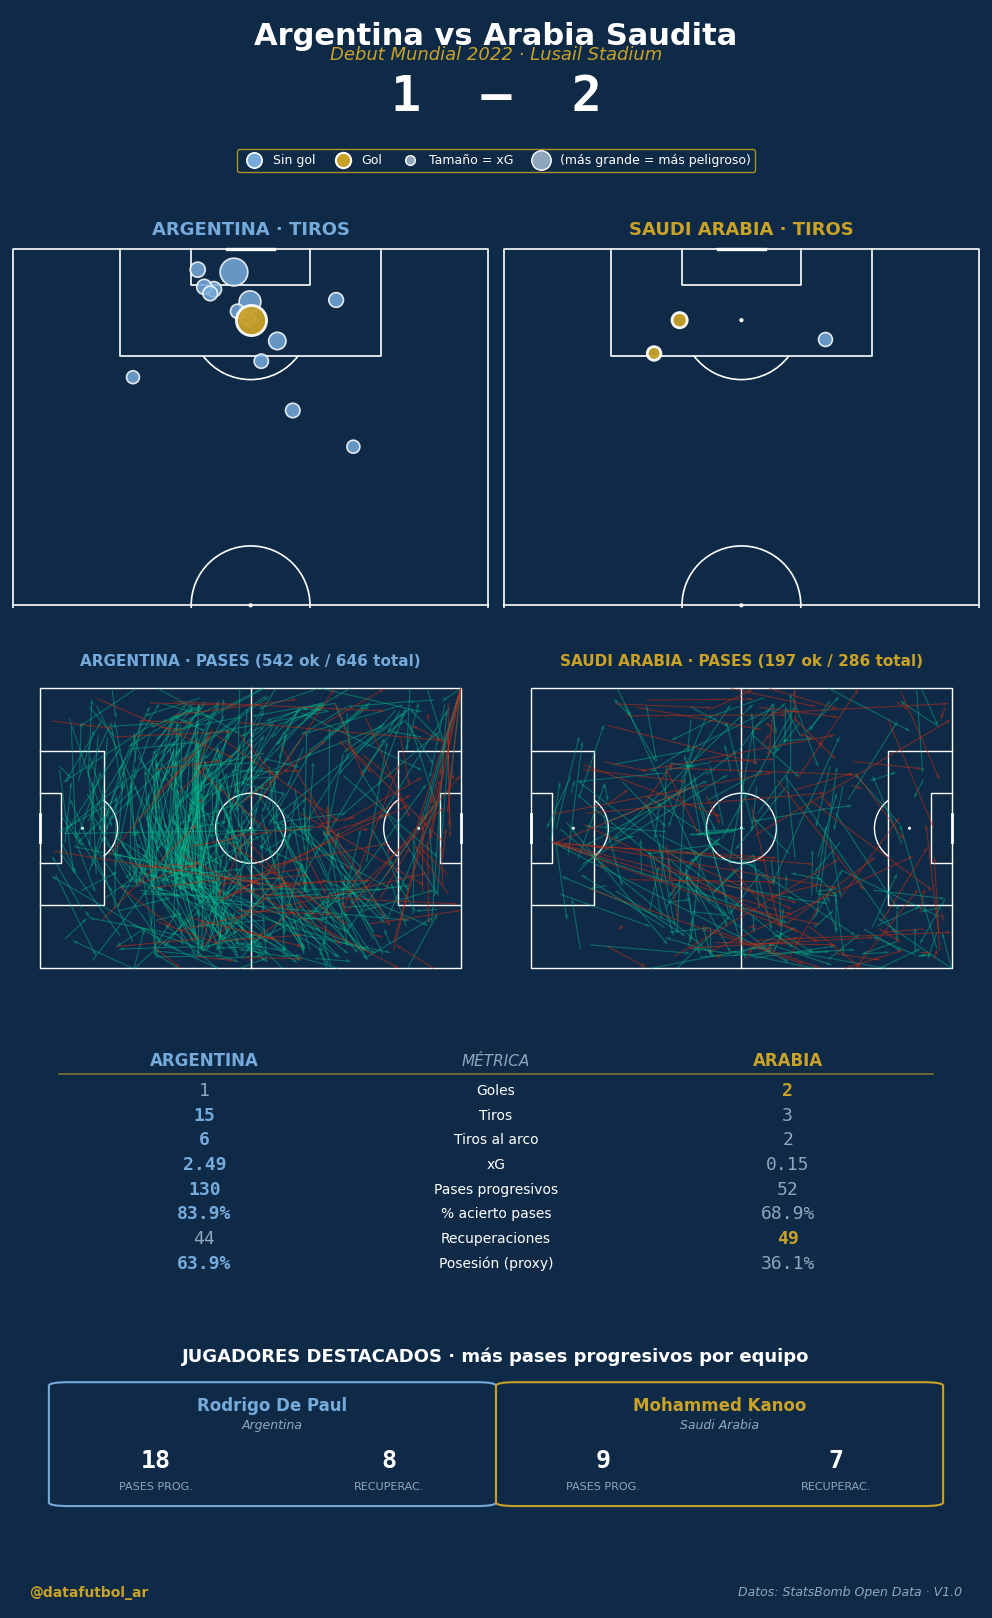

In [6]:
def dashboard_partido_v1(ev, stats_a, stats_b, dest_a, dest_b, archivo):
    """Dashboard A V1.0 — acerca shot maps + agrega leyenda explicativa + nombres bonitos."""
    fig = plt.figure(figsize=(10.8, 17.0), dpi=100, facecolor=COLORS['bg'])
    # NUEVA fila para la leyenda de los shot maps (entre header y shot maps)
    gs = gridspec.GridSpec(
        nrows=7, ncols=2,
        height_ratios=[1.0, 0.5, 5.0, 4.0, 3.2, 2.4, 0.4],
        #            header leyenda shots passes tabla dest footer
        hspace=0.30,
        wspace=0.02,  # ← CORRECCIÓN #4 de Federico
        left=0.05, right=0.95, top=0.97, bottom=0.03
    )

    # ===== HEADER =====
    ax_head = fig.add_subplot(gs[0, :]); ax_head.axis('off')
    ax_head.text(0.5, 0.85, 'Argentina vs Arabia Saudita',
                 ha='center', va='top', color=COLORS['text'],
                 fontsize=22, weight='bold', transform=ax_head.transAxes)
    ax_head.text(0.5, 0.53, 'Debut Mundial 2022 · Lusail Stadium',
                 ha='center', va='top', color=COLORS['accent'],
                 fontsize=13, style='italic', transform=ax_head.transAxes)
    resultado = f"{stats_a['goles']}  –  {stats_b['goles']}"
    ax_head.text(0.5, 0.18, resultado, ha='center', va='top',
                 color=COLORS['text'], fontsize=36, weight='bold',
                 family='monospace', transform=ax_head.transAxes)

    # ===== NUEVA FILA: LEYENDA DE LOS SHOT MAPS =====
    ax_leg = fig.add_subplot(gs[1, :]); ax_leg.axis('off')
    handles_shots = [
        Line2D([0], [0], marker='o', linestyle='', markersize=11,
               markerfacecolor=COLORS['primary'], markeredgecolor=COLORS['text'],
               markeredgewidth=1.2, label='Sin gol'),
        Line2D([0], [0], marker='o', linestyle='', markersize=11,
               markerfacecolor=COLORS['accent'], markeredgecolor=COLORS['text'],
               markeredgewidth=1.5, label='Gol'),
        Line2D([0], [0], marker='o', linestyle='', markersize=7,
               markerfacecolor=COLORS['muted'], markeredgecolor=COLORS['text'],
               label='Tamaño = xG'),
        Line2D([0], [0], marker='o', linestyle='', markersize=14,
               markerfacecolor=COLORS['muted'], markeredgecolor=COLORS['text'],
               label='(más grande = más peligroso)'),
    ]
    leg = ax_leg.legend(handles=handles_shots, loc='center',
                        ncol=4, facecolor=COLORS['bg'], edgecolor=COLORS['accent'],
                        labelcolor=COLORS['text'], fontsize=9, framealpha=0.85,
                        handletextpad=0.5, columnspacing=1.2)

    # ===== FILA 2: SHOT MAPS — CORRECCIÓN #4 =====
    def _shot_map(ax, equipo, color_resaltado):
        tiros = ev[(ev['type'] == 'Shot') & (ev['team'] == equipo)].copy()
        pitch = VerticalPitch(pitch_type='statsbomb', pitch_color=COLORS['bg'],
                              line_color=COLORS['text'], linewidth=1.2,
                              half=True,
                              pad_top=0.5, pad_bottom=0.5,
                              pad_left=0.5, pad_right=0.5)
        pitch.draw(ax=ax); ax.set_facecolor(COLORS['bg'])
        es_gol = tiros['shot_outcome'] == 'Goal'
        size = tiros['shot_statsbomb_xg'] * 500 + 80
        pitch.scatter(tiros.loc[~es_gol, 'x'], tiros.loc[~es_gol, 'y'],
                       s=size[~es_gol], ax=ax, color=COLORS['primary'],
                       edgecolors=COLORS['text'], linewidth=1.2,
                       alpha=0.85, zorder=2)
        if es_gol.any():
            pitch.scatter(tiros.loc[es_gol, 'x'], tiros.loc[es_gol, 'y'],
                           s=size[es_gol], ax=ax, color=COLORS['accent'],
                           edgecolors=COLORS['text'], linewidth=2,
                           alpha=0.95, zorder=3)
        ax.set_title(f'{equipo.upper()} · TIROS',
                     color=color_resaltado, fontsize=13, weight='bold', pad=8)

    _shot_map(fig.add_subplot(gs[2, 0]), 'Argentina', COLORS['primary'])
    _shot_map(fig.add_subplot(gs[2, 1]), 'Saudi Arabia', COLORS['accent'])

    # ===== FILA 3: PASS MAPS =====
    def _pass_map(ax, equipo, color_resaltado):
        pases = ev[(ev['type'] == 'Pass') & (ev['team'] == equipo)].copy()
        pases = agregar_pases_progresivos(pases)
        pitch = Pitch(pitch_type='statsbomb', pitch_color=COLORS['bg'],
                      line_color=COLORS['text'], linewidth=1.0, pad_top=4)
        pitch.draw(ax=ax); ax.set_facecolor(COLORS['bg'])
        ok = pases['es_completado']
        pitch.arrows(pases.loc[ok, 'x'], pases.loc[ok, 'y'],
                     pases.loc[ok, 'x_end'], pases.loc[ok, 'y_end'],
                     ax=ax, width=0.8, headwidth=3, color=COLOR_OK,
                     alpha=0.45, zorder=2)
        pitch.arrows(pases.loc[~ok, 'x'], pases.loc[~ok, 'y'],
                     pases.loc[~ok, 'x_end'], pases.loc[~ok, 'y_end'],
                     ax=ax, width=0.8, headwidth=3, color=COLOR_NO_OK,
                     alpha=0.55, zorder=3)
        ax.set_title(f"{equipo.upper()} · PASES ({int(ok.sum())} ok / {len(pases)} total)",
                     color=color_resaltado, fontsize=11, weight='bold', pad=6)

    _pass_map(fig.add_subplot(gs[3, 0]), 'Argentina', COLORS['primary'])
    _pass_map(fig.add_subplot(gs[3, 1]), 'Saudi Arabia', COLORS['accent'])

    # ===== TABLA COMPARATIVA =====
    ax_tab = fig.add_subplot(gs[4, :]); ax_tab.axis('off')
    metricas = [
        ('Goles', stats_a['goles'], stats_b['goles']),
        ('Tiros', stats_a['tiros'], stats_b['tiros']),
        ('Tiros al arco', stats_a['tiros_al_arco'], stats_b['tiros_al_arco']),
        ('xG', stats_a['xg'], stats_b['xg']),
        ('Pases progresivos', stats_a['pases_progresivos'], stats_b['pases_progresivos']),
        ('% acierto pases', f"{stats_a['acierto_pct']}%", f"{stats_b['acierto_pct']}%"),
        ('Recuperaciones', stats_a['recuperaciones'], stats_b['recuperaciones']),
        ('Posesión (proxy)', f"{stats_a['posesion']}%", f"{stats_b['posesion']}%"),
    ]
    n = len(metricas); y_top = 0.95; y_bot = 0.05
    row_h = (y_top - y_bot) / (n + 1)
    ax_tab.text(0.20, y_top - row_h*0.5, 'ARGENTINA', ha='center', va='center',
                color=COLORS['primary'], fontsize=12, weight='bold', transform=ax_tab.transAxes)
    ax_tab.text(0.50, y_top - row_h*0.5, 'MÉTRICA', ha='center', va='center',
                color=COLORS['muted'], fontsize=11, style='italic', transform=ax_tab.transAxes)
    ax_tab.text(0.80, y_top - row_h*0.5, 'ARABIA', ha='center', va='center',
                color=COLORS['accent'], fontsize=12, weight='bold', transform=ax_tab.transAxes)
    ax_tab.plot([0.05, 0.95], [y_top - row_h, y_top - row_h],
                color=COLORS['accent'], linewidth=1.2, alpha=0.6, transform=ax_tab.transAxes)
    for i, (nombre, val_a, val_b) in enumerate(metricas):
        y = y_top - row_h * (i + 1.7)
        try:
            num_a = float(str(val_a).rstrip('%'))
            num_b = float(str(val_b).rstrip('%'))
            color_a = COLORS['primary'] if num_a >= num_b else COLORS['muted']
            color_b = COLORS['accent']  if num_b >= num_a else COLORS['muted']
            peso_a = 'bold' if num_a >= num_b else 'normal'
            peso_b = 'bold' if num_b >= num_a else 'normal'
        except ValueError:
            color_a = color_b = COLORS['text']; peso_a = peso_b = 'normal'
        ax_tab.text(0.20, y, str(val_a), ha='center', va='center',
                    color=color_a, fontsize=13, weight=peso_a,
                    family='monospace', transform=ax_tab.transAxes)
        ax_tab.text(0.50, y, nombre, ha='center', va='center',
                    color=COLORS['text'], fontsize=10, transform=ax_tab.transAxes)
        ax_tab.text(0.80, y, str(val_b), ha='center', va='center',
                    color=color_b, fontsize=13, weight=peso_b,
                    family='monospace', transform=ax_tab.transAxes)

    # ===== DESTACADOS (con nombres bonitos) =====
    ax_dest = fig.add_subplot(gs[5, :]); ax_dest.axis('off')
    ax_dest.text(0.5, 0.95, 'JUGADORES DESTACADOS · más pases progresivos por equipo',
                 ha='center', va='top', color=COLORS['text'],
                 fontsize=13, weight='bold', transform=ax_dest.transAxes)
    def _card(ax, x_center, dest, color):
        if dest is None: return
        box = FancyBboxPatch((x_center - 0.22, 0.10), 0.44, 0.65,
            boxstyle="round,pad=0.01,rounding_size=0.02",
            facecolor=COLORS['bg'], edgecolor=color,
            linewidth=1.5, transform=ax.transAxes)
        ax.add_patch(box)
        nombre_corto = nombre_bonito(dest['nombre'], formato='completo')
        ax.text(x_center, 0.68, nombre_corto, ha='center', va='top',
                color=color, fontsize=12, weight='bold', transform=ax.transAxes)
        ax.text(x_center, 0.56, dest['equipo'], ha='center', va='top',
                color=COLORS['muted'], fontsize=9, style='italic', transform=ax.transAxes)
        ax.text(x_center - 0.12, 0.40, f"{dest['pases_progresivos']}",
                ha='center', va='top', color=COLORS['text'],
                fontsize=18, weight='bold', family='monospace', transform=ax.transAxes)
        ax.text(x_center - 0.12, 0.22, "PASES PROG.", ha='center', va='top',
                color=COLORS['muted'], fontsize=8, transform=ax.transAxes)
        ax.text(x_center + 0.12, 0.40, f"{dest['recuperaciones']}",
                ha='center', va='top', color=COLORS['text'],
                fontsize=18, weight='bold', family='monospace', transform=ax.transAxes)
        ax.text(x_center + 0.12, 0.22, "RECUPERAC.", ha='center', va='top',
                color=COLORS['muted'], fontsize=8, transform=ax.transAxes)
    _card(ax_dest, 0.27, dest_a, COLORS['primary'])
    _card(ax_dest, 0.73, dest_b, COLORS['accent'])

    # ===== FOOTER =====
    ax_foot = fig.add_subplot(gs[6, :]); ax_foot.axis('off')
    ax_foot.text(0.02, 0.5, '@datafutbol_ar', ha='left', va='center',
                 color=COLORS['accent'], fontsize=10, weight='bold', transform=ax_foot.transAxes)
    ax_foot.text(0.98, 0.5, 'Datos: StatsBomb Open Data · V1.0', ha='right', va='center',
                 color=COLORS['muted'], fontsize=9, style='italic', transform=ax_foot.transAxes)

    guardar_fig(fig, archivo)
    plt.show()


dashboard_partido_v1(ev, stats_arg, stats_sau, dest_arg, dest_sau,
                     'punto5_dashboard_partido_v1')


---

## Resumen — Punto 5 V1.0 ✅ (actualizado)

| Cambio | Antes (V0) | Ahora (V1.0) |
|---|---|---|
| `wspace` entre shot maps | `0.10` | `0.02` |
| `pad_*` del Pitch | default | `0.5` |
| **Leyenda shot maps** | ❌ no había | ✅ franja horizontal entre header y shot maps (4 elementos: sin gol, gol, tamaño chico, tamaño grande) |
| Nombre del destacado | "Rodrigo Paul" | "Rodrigo De Paul" (vía `nombres_bonitos.py`) |

### Lo que aprendí (lección extra del V1.0)

**Siempre que uses encoding visual (color o tamaño) para transmitir información, agregar leyenda explícita.** En V0 di por hecho que el lector entendía celeste=sin gol / dorado=gol / tamaño=xG, pero no es obvio para alguien que ve el dashboard sin contexto previo. La leyenda explica todo en una franja chiquita que no quita protagonismo a los datos.
